In [60]:
include("CRD_STA.jl")
include("LST_BEK.jl")
using Plots
using LinearAlgebra
using NonlinearEigenproblems
using ProgressMeter
using DelimitedFiles

In [156]:
num = 1
c = 0.38
A0,A1,A2,A3,A4 = KEB_SpatialMode.KEB_LST_ALL("Vonkarmen.txt",99,0,0.07759,285.36,1,2)
nep = PEP([A0,A1,A2,A3,A4]); 
eigval,eigvec = iar(nep,σ = c , neigs = num ,maxit = 500,tol=1e-10)
eigval

1-element Vector{ComplexF64}:
 0.3849581024779843 + 7.635477856237502e-5im

In [172]:
Tw = 1
N_cheb = 199
Mr = 1
gamma = 1.4
sigma = 0.72
omega = 0
R = 286
R_step = 0.2
be0 = 0.14
be1 = 0.16
be_step = 0.0002
c = 0.4
be = 0.07759
num = 1
Ma = Mr/R
u0,v0,w0,f,q,D,D2,x = baseflow_var(N_cheb,1,2)
H,T = T_ca(Mr,f,q,w0,gamma,Tw)
F,G,H,T,rho,z = interp(u0,v0,H,T,x,N_cheb,"sim")
lam = - (2/3) * T
kappa = (1/sigma) * T
num = 1
A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,1,2)
nep = PEP([A0,A1,A2]); 
eigval,eigvec = iar(nep , σ = c , neigs = num ,maxit = 500,tol=1e-10)
eigval

1-element Vector{ComplexF64}:
 0.39643634694282626 + 0.00630285103788484im

In [173]:
t1 = 1 .- (gamma-1)/2 * Mr^2 * f
t12 = 1 .- (gamma-1)/2 * Mr^2 * f + 0.2 * q
t08 = 1 .- (gamma-1)/2 * Mr^2 * f - 0.2 * q

10001-element Vector{Float64}:
 0.8
 0.8003180646778796
 0.8006353947695722
 0.8009519926120223
 0.8012678605333734
 0.8015830008530036
 0.8018974158815622
 0.8022111079210135
 0.8025240792646775
 0.8028363321972665
 ⋮
 0.999998053914164
 0.9999980547177085
 0.9999980555202304
 0.9999980563217306
 0.9999980571222107
 0.9999980579216718
 0.9999980587201155
 0.999998059517543
 0.9999980603139554

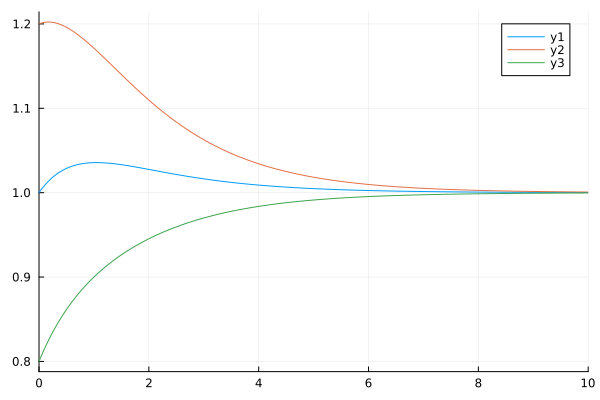

In [174]:
plot(t,t1)
plot!(t,t12)
plot!(t,t08,xlims = [0,10])

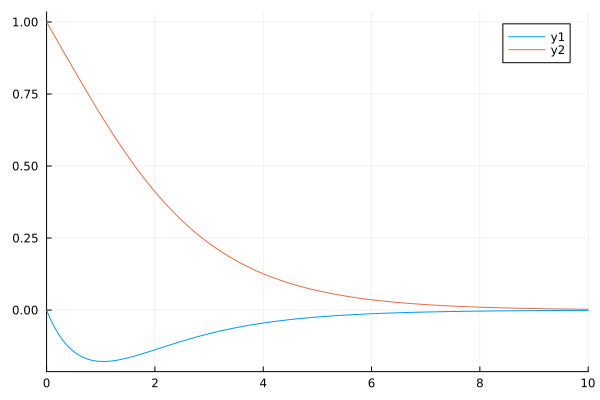

In [160]:
plot(t,f)
plot!(t,q,xlims=[0,10])

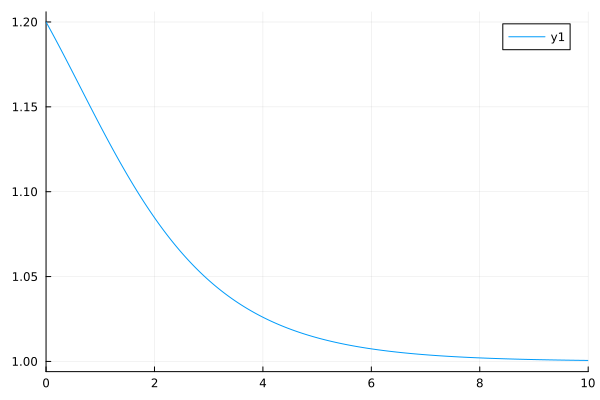

In [152]:
t = range(0,20,10001)
plot(t,d+e,xlims = [0,10])